# Verifying persona's prompts

We generated 5 prompts per persona per task. And then for subsequent analysis we pick 1 our of 5 for each persona. It is important to convince ourselves that this choice does not matter, and for a given task all paraphrases for the same persona are:
* More or less the same
* Differ significantly from paraphrases by other personas (for the same task)

This notebooks explores this question.

In [2]:
import spacy
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pylab as plt


In [3]:
df = pd.read_csv("../datasets/paraphrases_personas_21May.csv")

persona_keys = {
    "John": "Junior",
    "Brad": "Principal",
    "Harold": "Teacher",
    "Emmet": "Astrophysicist",
    "Harvey": "Manager"
}

df["persona_key"] = ""
df.loc[df["persona"].str.startswith('John'), "persona_key"] = persona_keys["John"]
df.loc[df["persona"].str.startswith('Brad'), "persona_key"] = persona_keys["Brad"]
df.loc[df["persona"].str.startswith('Harold'), "persona_key"] = persona_keys["Harold"]
df.loc[df["persona"].str.startswith('Emmet'), "persona_key"] = persona_keys["Emmet"]
df.loc[df["persona"].str.startswith('Harvey'), "persona_key"] = persona_keys["Harvey"]

## Attempt 1: semantic similarity with PCA

Our approach here is to convert all paraphrases to high dimentional embedding space and then use PCA to extract information that differentiates them the most. We are plotting first vs second PCA components in hope to see clear clustering.

In [ ]:
# embedding space 96 dimentions
nlp = spacy.load("en_core_web_sm")

# translate all paraphrases to the mebedding space
embeddings = []
for text in df["paraphrase"]:
    doc = nlp(text)
    embedding = doc.vector
    embeddings.append(embedding)

embeddings = np.array(embeddings)
embeddings.shape

(550, 96)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca_embeddings = pca.fit_transform(embeddings)
print(pca_embeddings)

df_with_2d_pca = df.copy(deep=True)
df_with_2d_pca['c1'] = pca_embeddings[:,0]
df_with_2d_pca['c2'] = pca_embeddings[:,1]

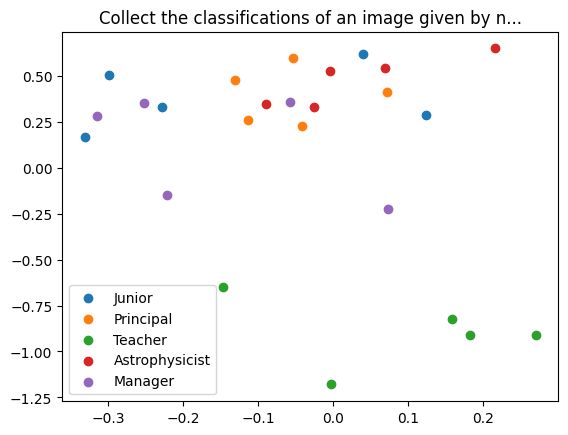

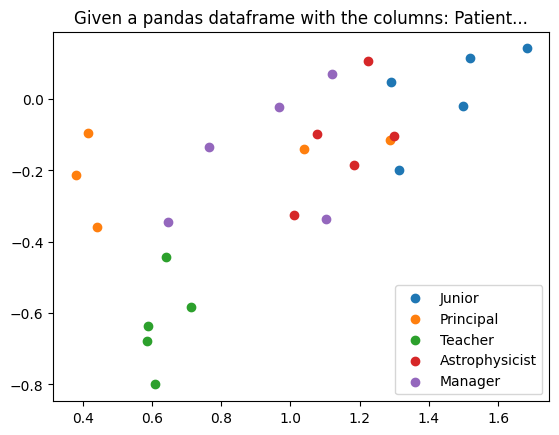

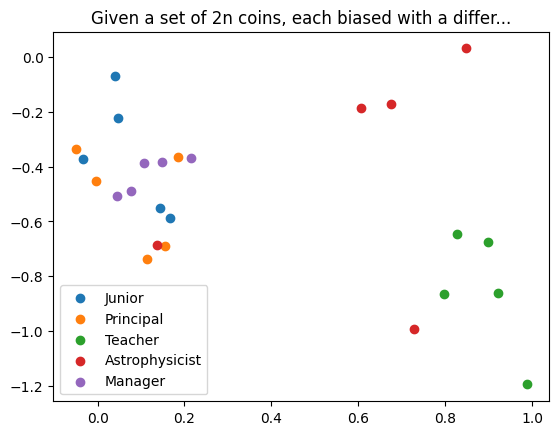

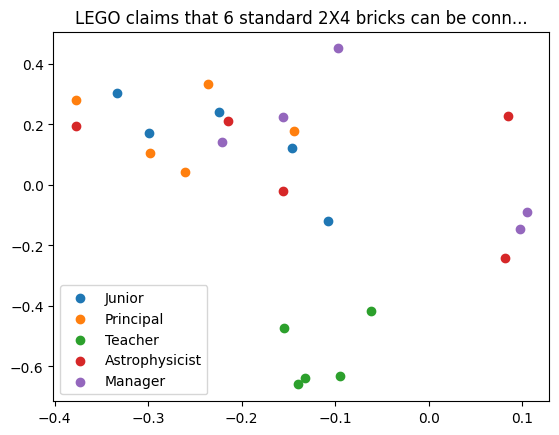

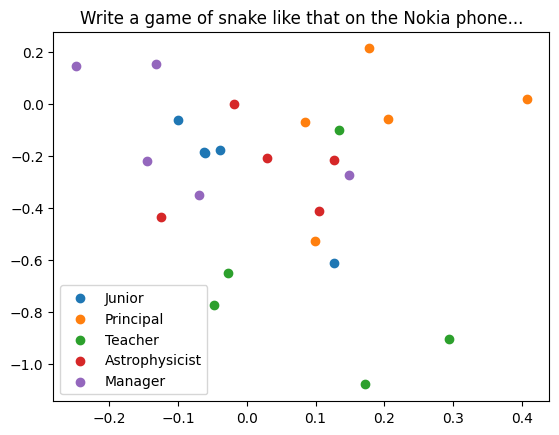

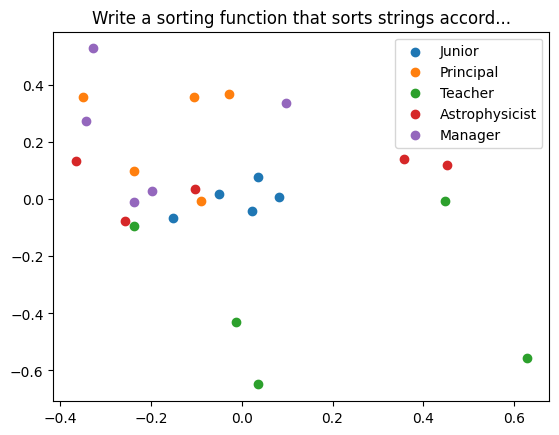

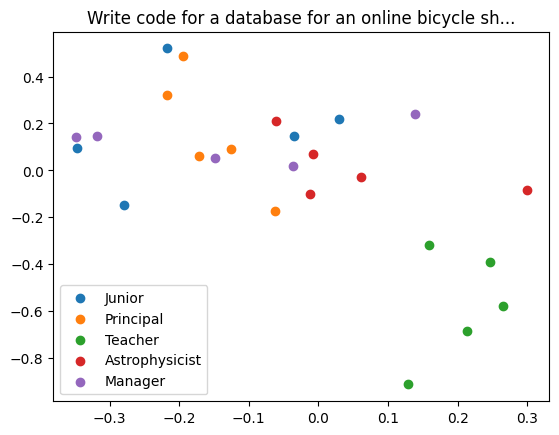

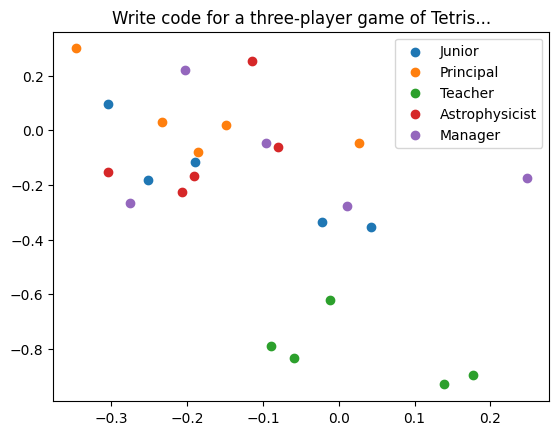

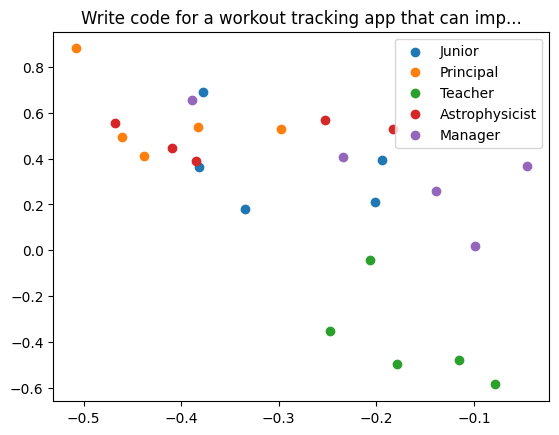

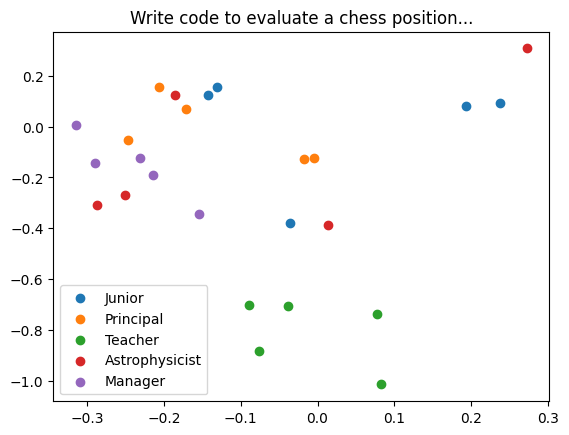

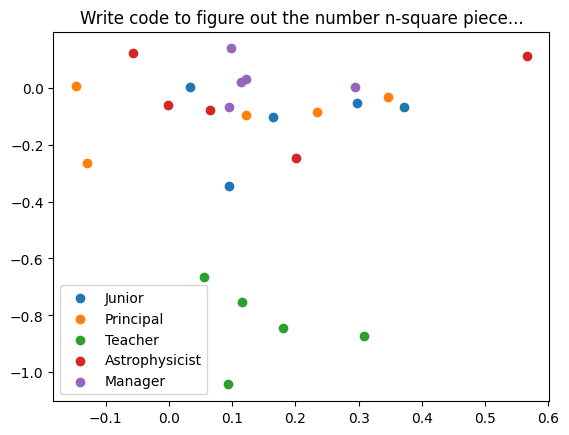

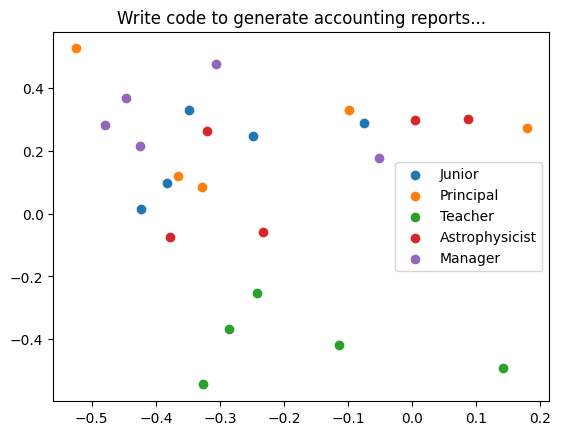

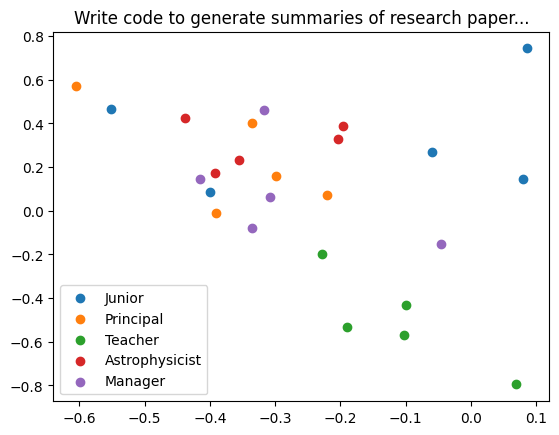

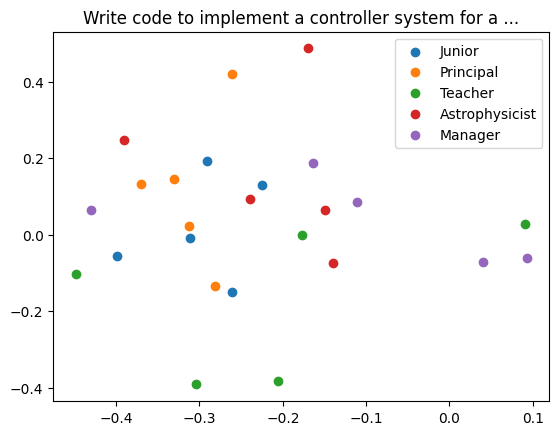

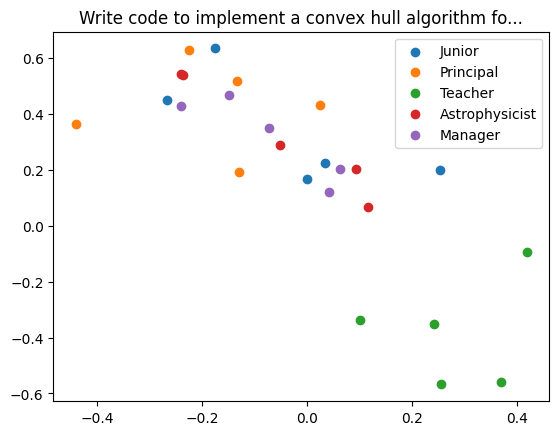

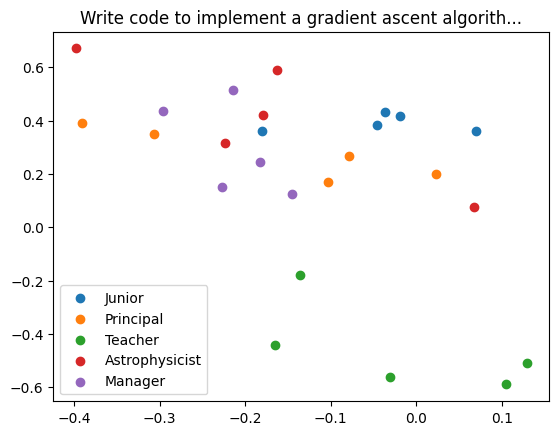

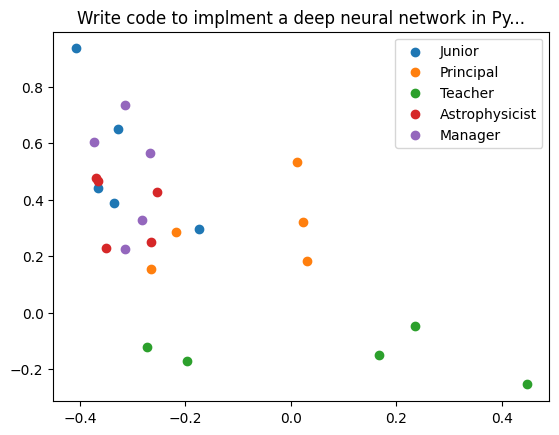

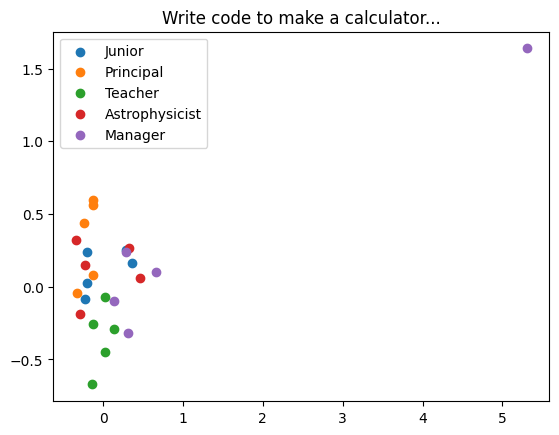

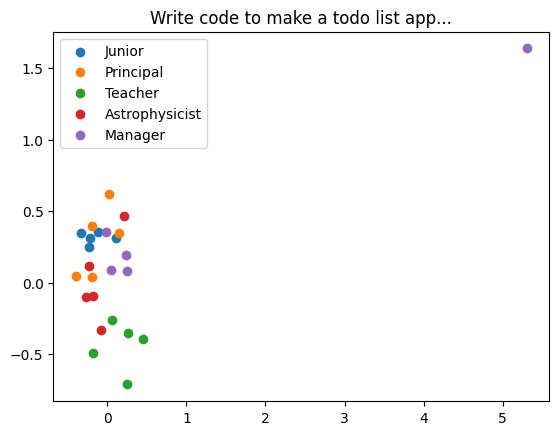

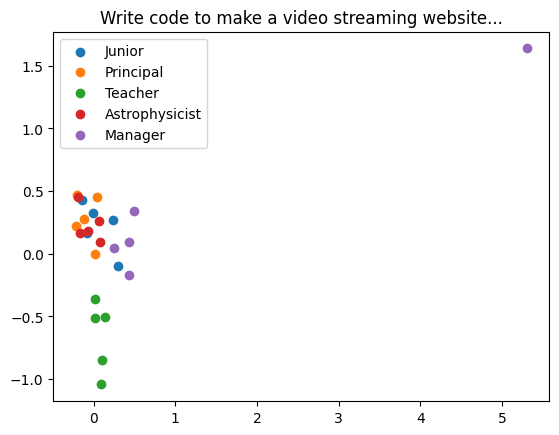

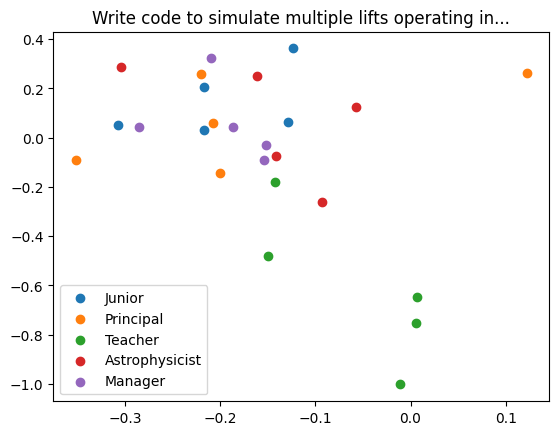

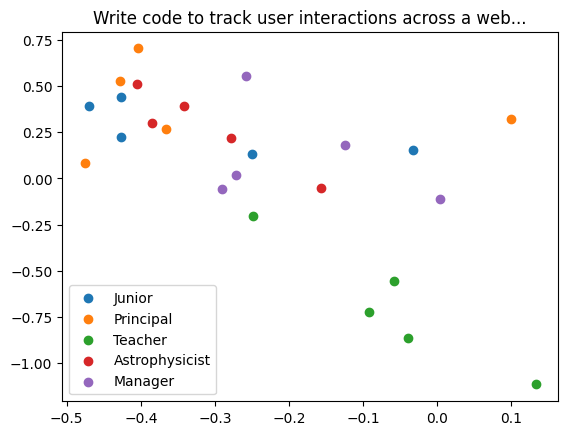

In [17]:
for group in df_with_2d_pca.groupby("original_phrase"):
    original_phrase = group[0]

    for key in persona_keys.values():
        persona_df = group[1][group[1]["persona_key"] == key] 
        plt.scatter(persona_df['c1'], persona_df['c2'], label=key)

    plt.legend()
    plt.title(original_phrase[:50]+"...")
    plt.show()

## Attempt 2: semantic similarity with t-SNE

Our approach here is to convert all paraphrases to high dimentional embedding space and then use dimentionality reduction with t-SNE to project high dimentional points on 2D plots. Hopefully we'll see clusters of prompts belonging to each persona, clearly separable from prompts by other personas.

In [ ]:
# embedding space 500 dimentions
nlp = spacy.load("en_core_web_lg")

# translate all paraphrases to the mebedding space
embeddings = []
for text in df["paraphrase"]:
    doc = nlp(text)
    embedding = doc.vector
    embeddings.append(embedding)

embeddings = np.array(embeddings)
embeddings.shape

In [38]:
# t-SNE is the dimentionality reduction method
# we use it to project 500 dims to 2 dims

tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='random', learning_rate="auto")
vis_dims = tsne.fit_transform(embeddings)
print(vis_dims.shape)

# for convenience of plotting copy 2d dims to the original dataframe
df_with_2d_embeddings = df.copy(deep=True)
df_with_2d_embeddings['x'] = vis_dims[:,0]
df_with_2d_embeddings['y'] = vis_dims[:,1]

(550, 2)


Below we make a 2D plot of embeddings for each task. We hope to see clear clusters for each persona. But unfortunately this is not the case - we can clearly separate "Teacher" in most plots, and there are no other clusters.

The most likely explanation for this is that in such a lower dimentional represetation only the very essense of the message remains represented, and the essense of the prompts is the same for all paraphrases by design. Therefore scroll down for Attempt 2, rethinking our approach!

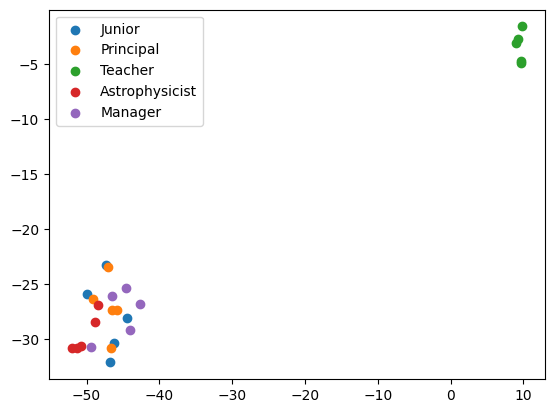

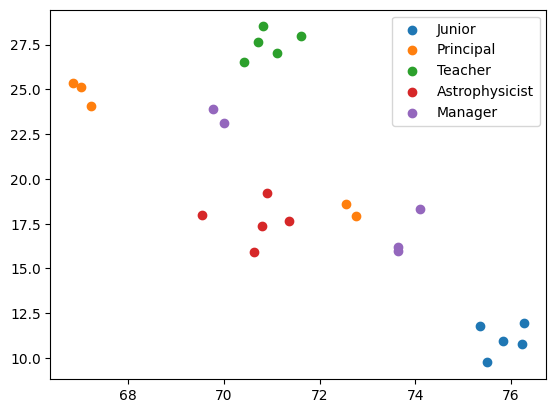

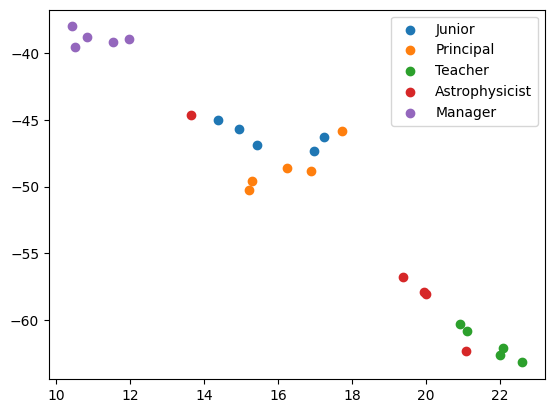

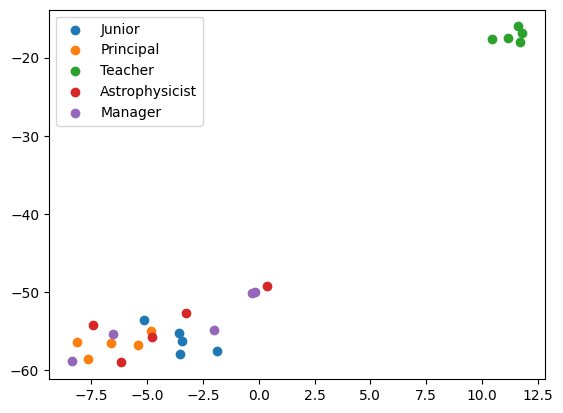

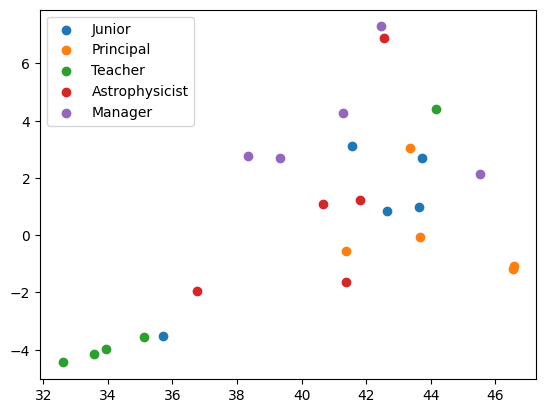

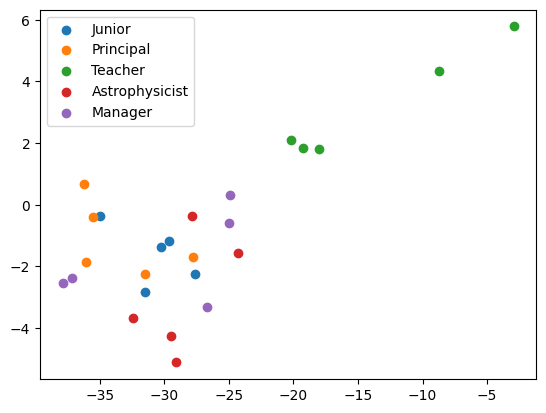

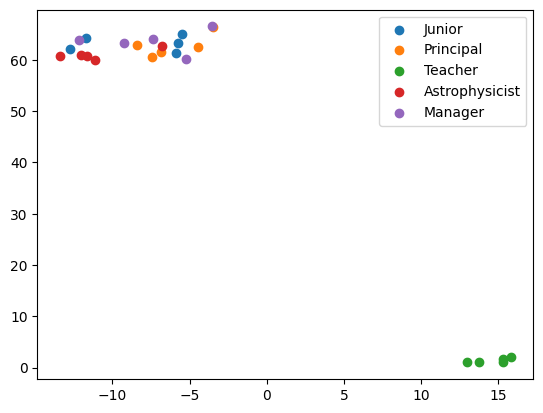

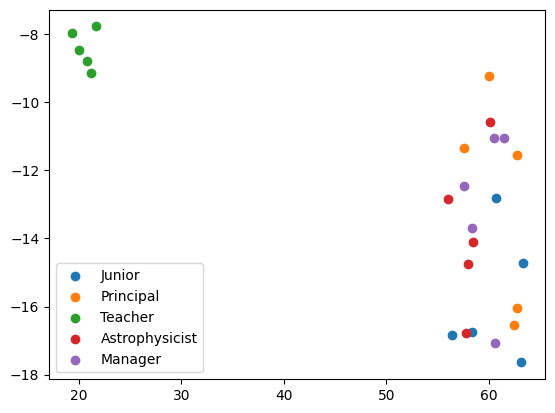

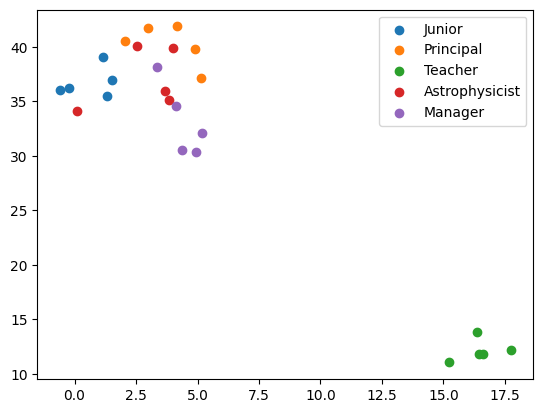

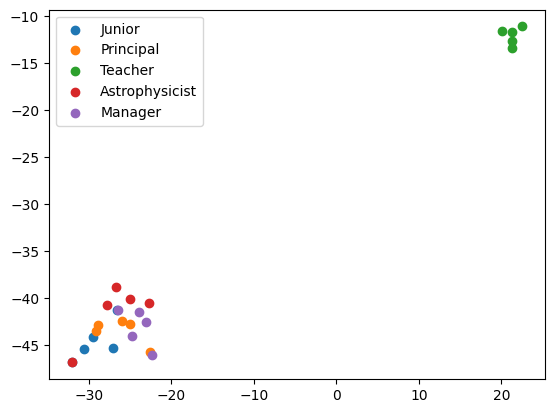

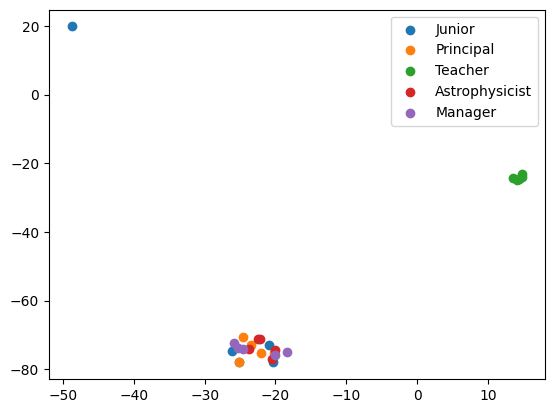

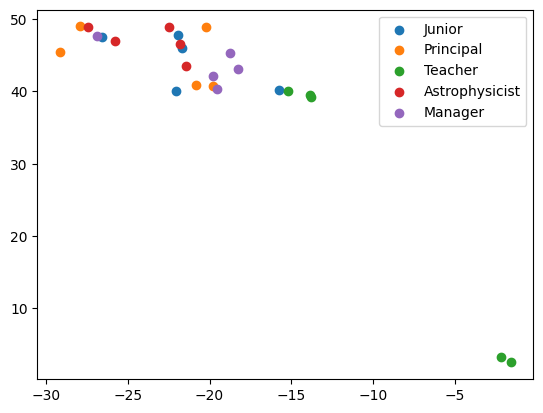

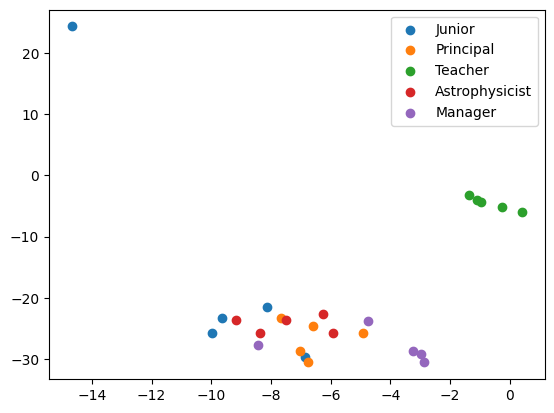

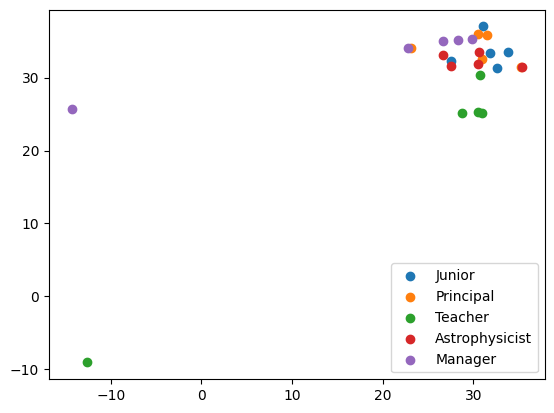

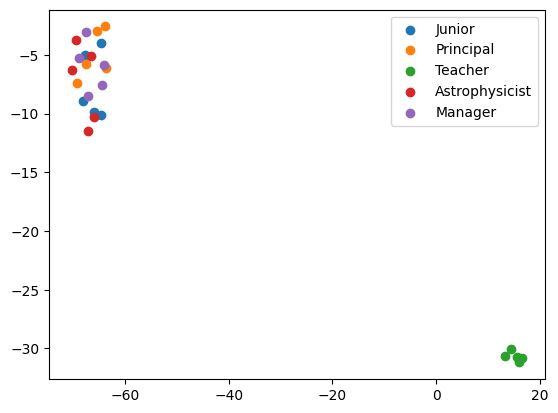

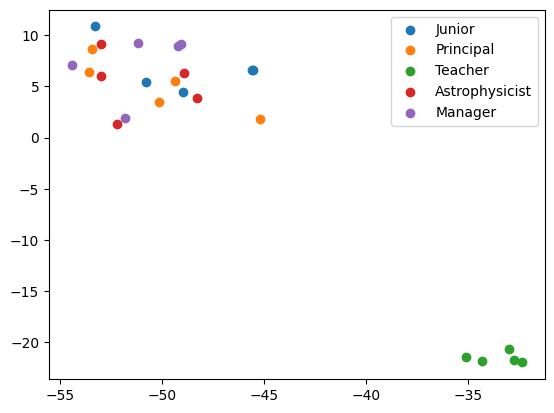

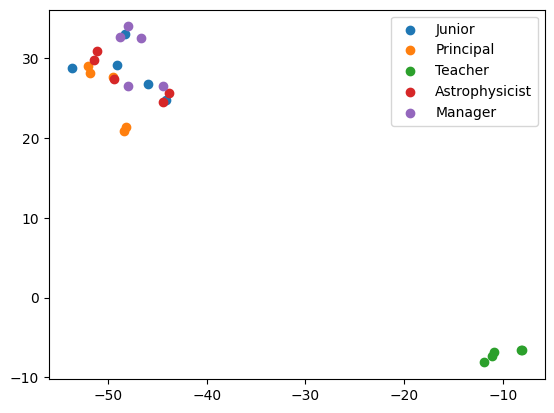

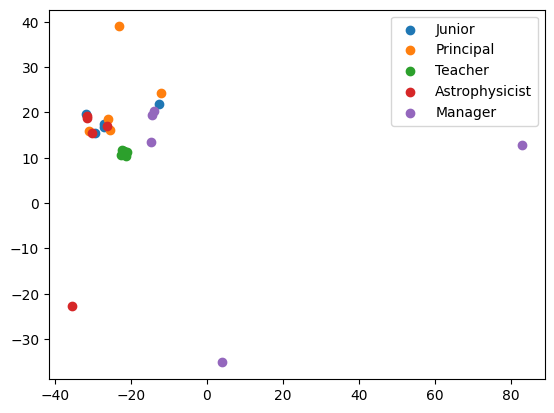

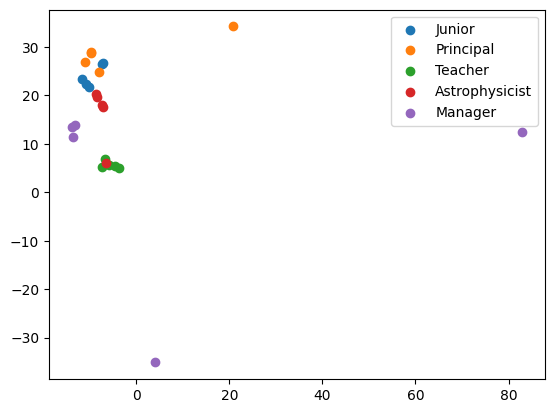

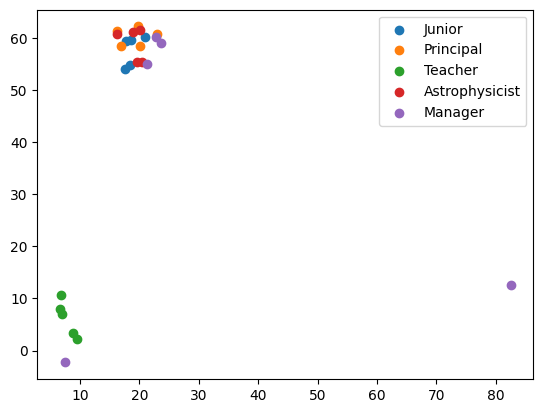

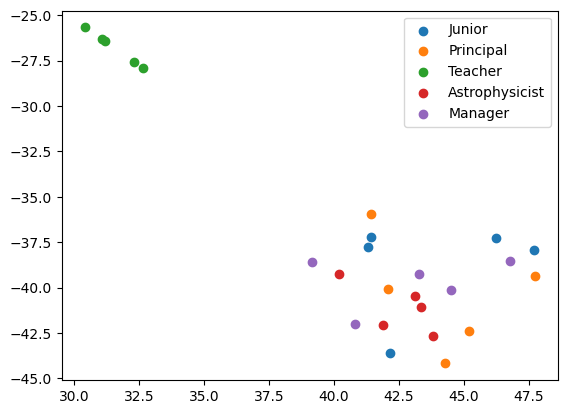

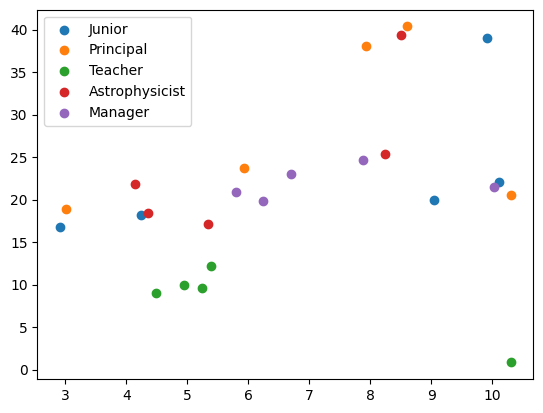

In [39]:
for group in df_with_2d_embeddings.groupby("original_phrase"):
    original_phrase = group[0]

    for key in persona_keys.values():
        persona_df = group[1][group[1]["persona_key"] == key] 
        plt.scatter(persona_df['x'], persona_df['y'], label=key)

    plt.legend()
    plt.show()

## Attempt 3: choice of words

Experiment above showed that semantically prompts cannot be separated for a given task, at least in 2D embedding space. And that makes sense, because they were designed to convey the same task. However, we hypothesise that what truly separates them is the vocabulary - choice of words typical for each persona should be, in theory, reasonably different.

Embeddings won't help with this, as they are designed to represent meanings. So instead we turn to BLEU score - a metric that reflects difference between words used in two different texts (apparently widely used for translations). We will calculate pairwise distances between paraphrases for a given task. Hopefully distances between prompts of one persona are small, and distances between prompts of two personas are big(ger). Let's see.

In [40]:
import torchmetrics

sacre_bleu_metric = torchmetrics.text.SacreBLEUScore().to('cpu')
bleu_metric_fn = lambda p1, p2: sacre_bleu_metric([p1], [[p2]]).item()

In [41]:
# a function to calculate pairwise distances given metric function

def pairwise_scores(paraphrases, metric_fn):
    all_scores = []
    for i, p1 in enumerate(paraphrases):
        p1_scores = []
        for j, p2 in enumerate(paraphrases):
            # a trick to ignore comparison of a prompts against itself
            # that always gets super high score and therefore can be distracting
            if i == j:
                p1_scores.append(0)
                continue

            score = metric_fn(p1, p2)
            p1_scores.append(score)
        all_scores.append(p1_scores)

    # convert list of lists to numpy
    all_scores = np.stack(all_scores)

    return all_scores

We now plot lower diagonal heatmaps, one plot per task. Each heatmap shows pairwise BLEU scores between all paraphrases for the task. First five belong to first persona, second five to second, etc. Again, we hope for a clear clusters to emerge - first five should have higher scores between themselves, but lower scores with other paraphrases. Similarly for second group of 5 prompts, and so on. Unfortunately, this is hardly the case in the plots we see.

Note: higher BLEU means smaller distance, or higher similarity.

The only hypothesis (Andrei has) so far is that even if prompts are different, they nevertheless use a lot of same vocabulary: "write/create/generate code", "software", "task". For each task also words must be shared, e.g. all prompts for bycicle shop website naturally would use "bycicle" and "shop". It is not clear how to avoid this effect.

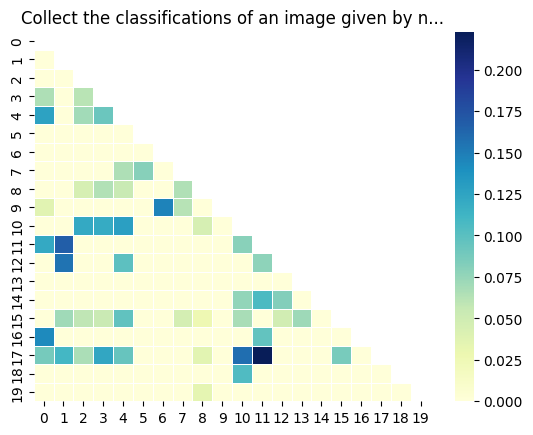

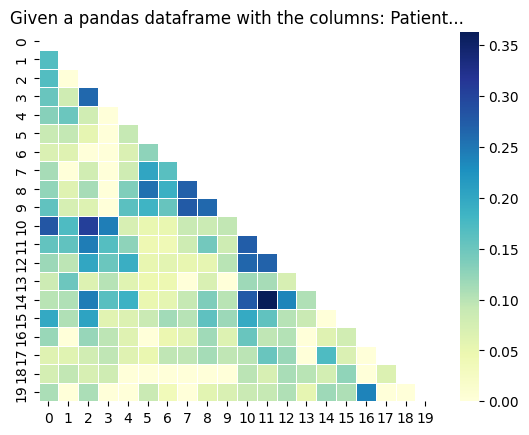

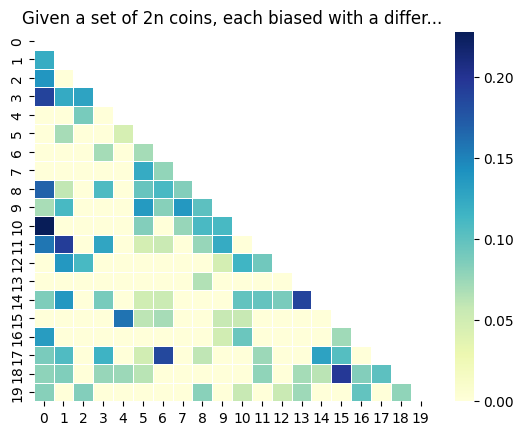

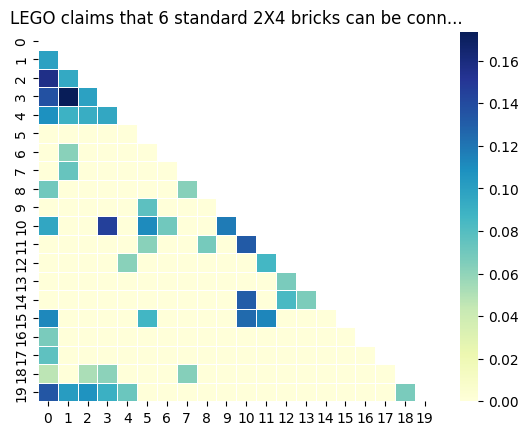

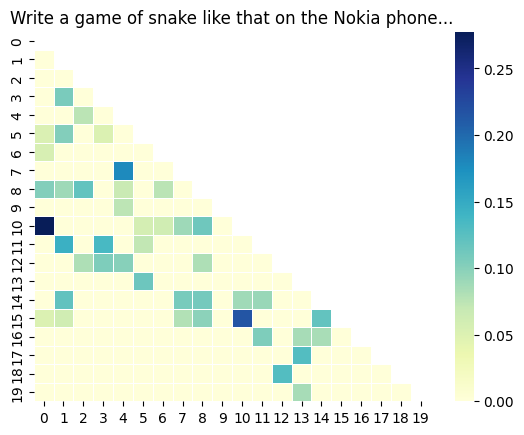

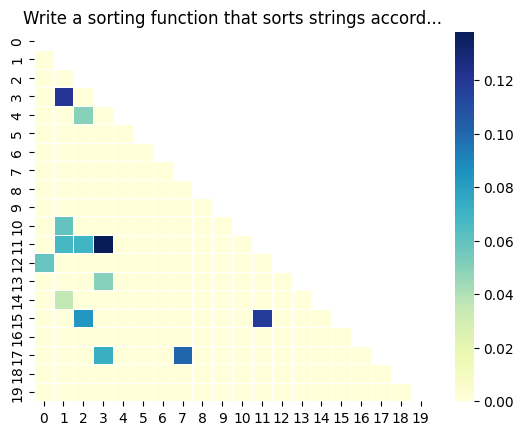

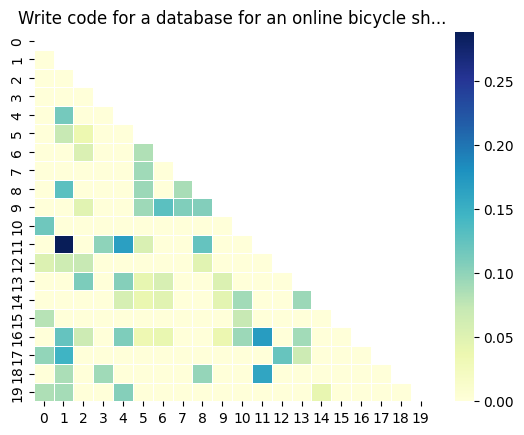

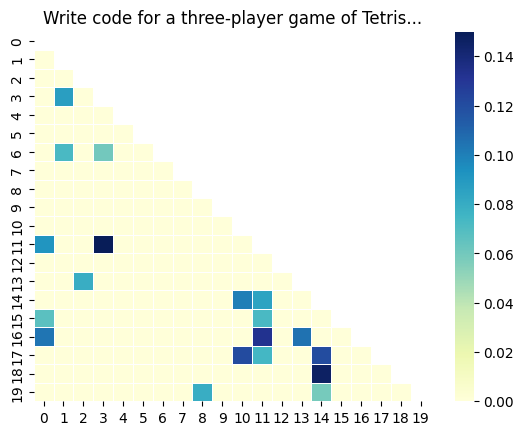

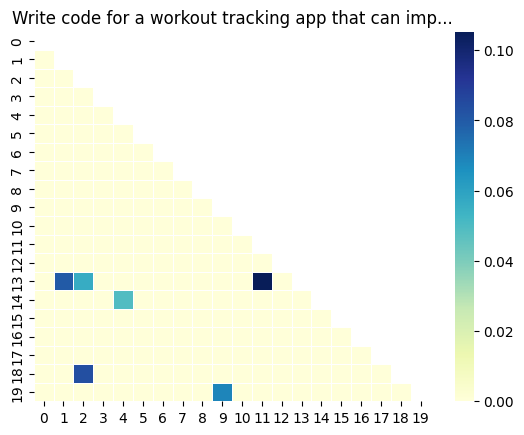

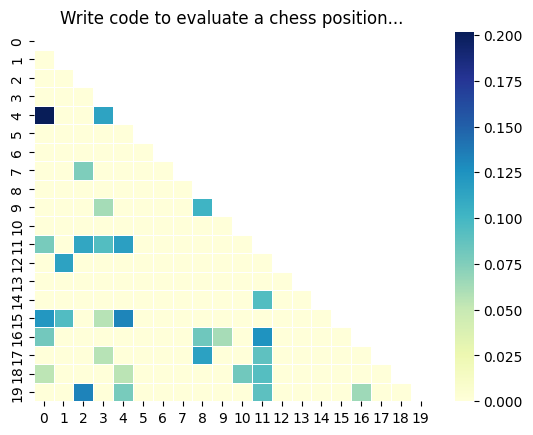

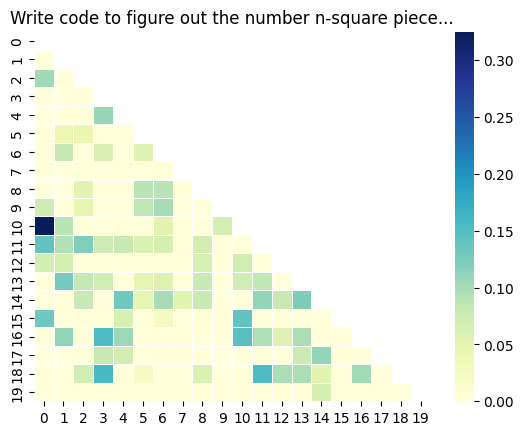

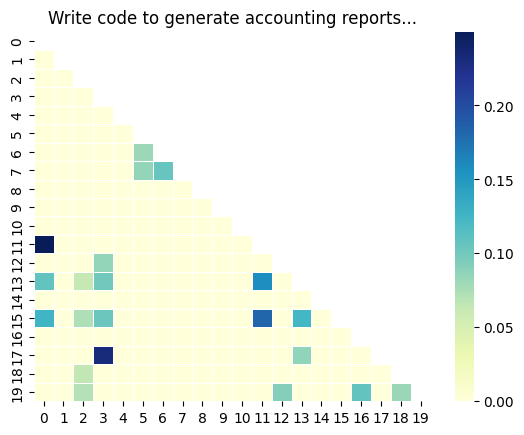

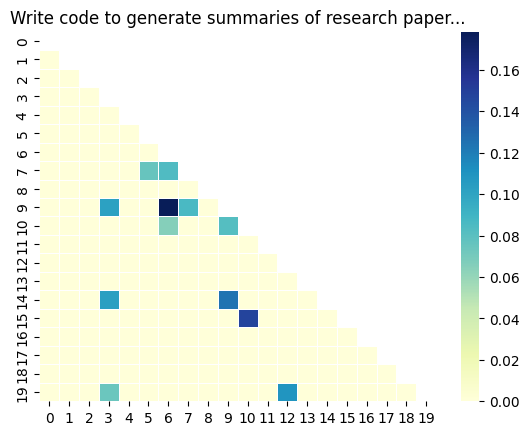

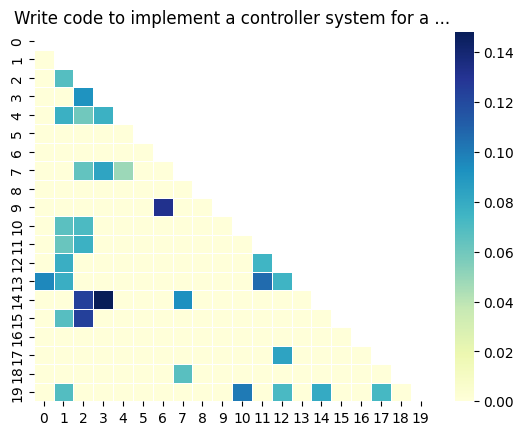

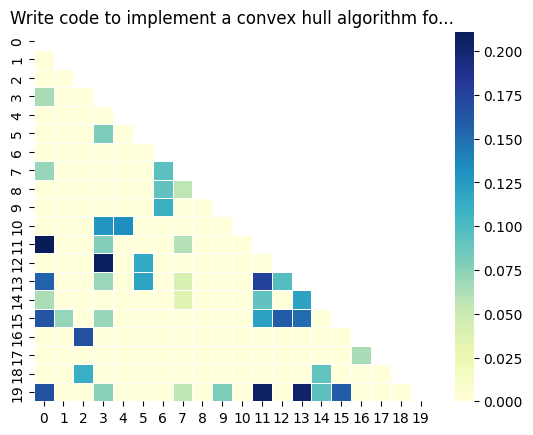

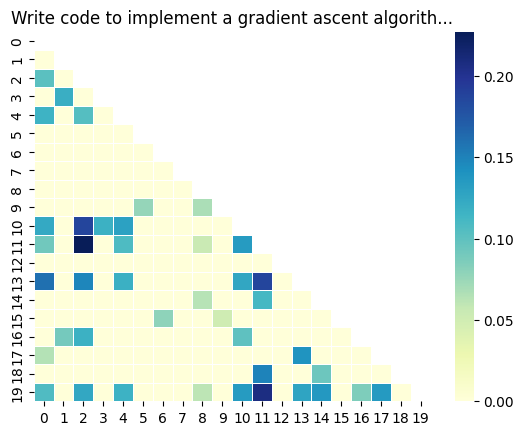

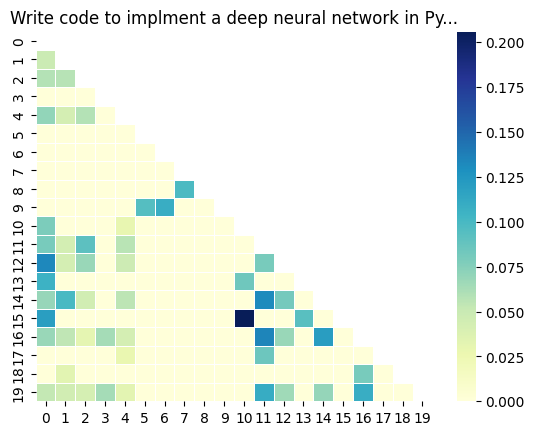

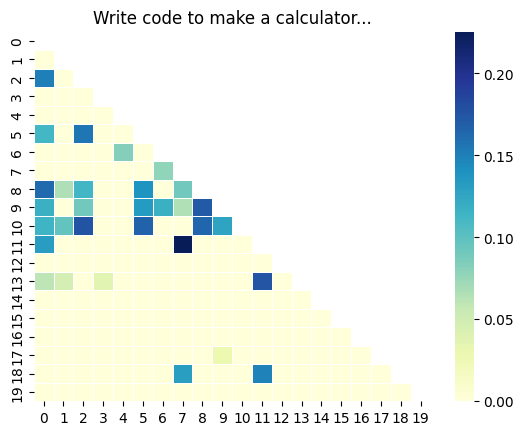

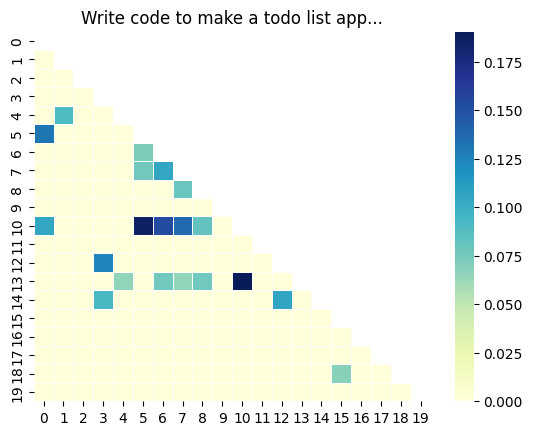

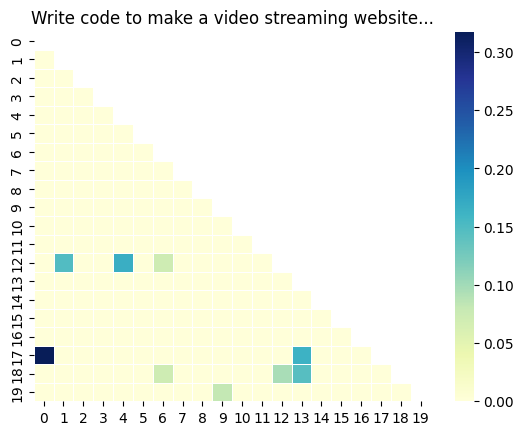

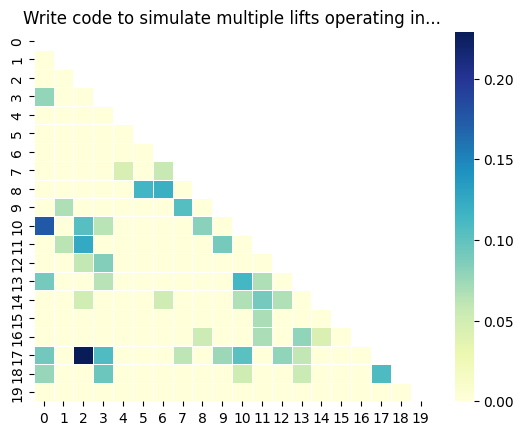

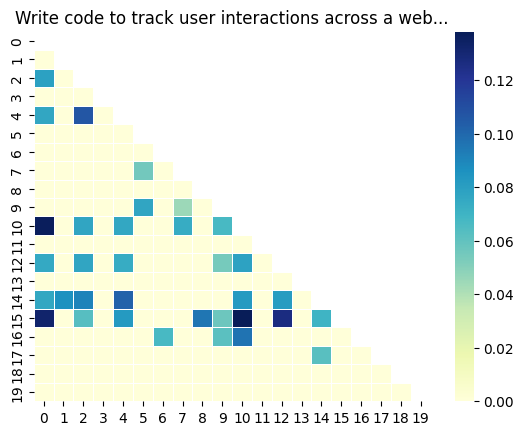

In [42]:
for group in df.groupby("original_phrase"):
    original_phrase = group[0]
    group_df = group[1]
    
    # let's keep only one engineer for now
    paraphrases = group_df[group_df["persona_key"] != persona_keys["John"]]["paraphrase"]

    metrics = pairwise_scores(paraphrases, bleu_metric_fn)

    matrix = np.triu(np.ones_like(metrics))
    sns.heatmap(metrics, linewidth=0.5, cmap="YlGnBu", mask=matrix)
    plt.title(original_phrase[:50] + "...")
    plt.show()
